### LIBRARY IMPORTS

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import copy
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

if os.getcwd().endswith('notebooks'):
    os.chdir('..')

from src import *
from src.data_manager import DataManager
from src.processor import Processor
from src.nn_regressor import NNRegressor
from src.gb_regressor import GBRegressor

### CONFIGURATION

In [3]:
data_manager = DataManager()

datasets_config, modeling_config = data_manager.load_config()

active_dataset = modeling_config["main"]["active_dataset"]
active_dataset_config = datasets_config[active_dataset]
target = active_dataset_config["target"]

problem_type = active_dataset_config["problem_type"]

gradient_boosting_config = modeling_config["gradient_boosting"]

weak_learner_key = gradient_boosting_config["weak_learner_key"]
weak_learner_config = modeling_config[weak_learner_key]

processor = Processor(**active_dataset_config)

raw_train, raw_test = data_manager.load_raw_data()
raw_train = processor.cut_data(raw_train)

### CROSS-VALIDATION

In [4]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def my_cross_validation(model, data, target, kf, processor):
    mse_scores = []
    r2_scores = []
    oof_preds = np.zeros(len(data))

    for train_idx, valid_idx in kf.split(data):
        train_df = raw_train.iloc[train_idx]
        valid_df = raw_train.iloc[valid_idx]

        train_proc = processor.fit_transform(train_df)
        valid_proc = processor.transform(valid_df)

        X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
        X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

        model.fit(X_train, y_train)

        preds = model.predict(X_valid)
        oof_preds[valid_idx] = preds

        fold_mse = mean_squared_error(y_valid, preds)
        fold_r2 = r2_score(y_valid, preds)
        
        mse_scores.append(fold_mse)
        r2_scores.append(fold_r2)
    
    return mse_scores, r2_scores, oof_preds

### RIDGE REGRESSION

In [5]:
%%time

ridge = Ridge(alpha=1.0, random_state=42)
ridge_mse_scores, ridge_r2_scores, ridge_oof_preds = my_cross_validation(ridge, raw_train, target, kf, processor)

CPU times: total: 1.11 s
Wall time: 1.1 s


In [6]:
print("Ridge MSE scores:", ridge_mse_scores)
print("Ridge R2 scores:", ridge_r2_scores)

Ridge MSE scores: [0.01206151807514626, 0.012292627662309843, 0.012080486735903177, 0.01227748025803125, 0.012255805037537999]
Ridge R2 scores: [0.7801613291103521, 0.7780645197870598, 0.7791724013834471, 0.7769449852617083, 0.7756258485946159]


### DECISION TREE

In [7]:
%%time

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_mse_scores, dt_r2_scores, dt_oof_preds = my_cross_validation(dt, raw_train, target, kf, processor)

CPU times: total: 1.8 s
Wall time: 1.8 s


In [8]:
print("Decision tree MSE scores:", dt_mse_scores)
print("Decision tree R2 scores:", dt_r2_scores)

Decision tree MSE scores: [0.017833131175414893, 0.018043508431977214, 0.01791111399581419, 0.018086290485257433, 0.01804981931225231]
Decision tree R2 scores: [0.6749653044518265, 0.6742360690826752, 0.6725903203479433, 0.6714115839761872, 0.6695514591817715]


### RANDOM FOREST

In [9]:
%%time

rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_mse_scores, rf_r2_scores, rf_oof_preds = my_cross_validation(rf, raw_train, target, kf, processor)

CPU times: total: 53.8 s
Wall time: 54 s


In [10]:
print("Random forest MSE scores:", rf_mse_scores)
print("Random forest R2 scores:", rf_r2_scores)

Random forest MSE scores: [0.01667669954798179, 0.016918746225209624, 0.0168425641186361, 0.016951252744353558, 0.01689960982579473]
Random forest R2 scores: [0.6960429491036638, 0.6945429267653251, 0.6921230849242217, 0.6920327419585197, 0.6906090132691516]


### NEURAL NETWORK

In [11]:
%%time

mlp = NNRegressor(epochs=5, learning_rate=0.01, hidden_size=64, batch_size=1024)

mlp_mse_scores = []
mlp_r2_scores = []
mlp_oof_preds = np.zeros(len(raw_train))

for train_idx, valid_idx in kf.split(raw_train):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    mlp.fit(X_train.values, y_train.values)

    preds = mlp.predict(X_valid.values).ravel()
    mlp_oof_preds[valid_idx] = preds

    fold_mse = mean_squared_error(y_valid, preds)
    fold_r2 = r2_score(y_valid, preds)
    
    mlp_mse_scores.append(fold_mse)
    mlp_r2_scores.append(fold_r2)

CPU times: total: 48.7 s
Wall time: 19.5 s


In [12]:
print("Neural network MSE scores:", mlp_mse_scores)
print("Neural network R2 scores:", mlp_r2_scores)

Neural network MSE scores: [0.012318255426474101, 0.012407392401992763, 0.012210248878673568, 0.012366068398958385, 0.012368898479071782]
Neural network R2 scores: [0.7754819182988769, 0.7759925162811587, 0.7768003891453839, 0.7753355321276083, 0.7735553811797103]


### GRADIENT BOOSTING (DTs)

In [13]:
%%time

gb_mse_scores = []
gb_r2_scores = []
gb_oof_preds = np.zeros(len(raw_train))

for train_idx, valid_idx in kf.split(raw_train):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    gb = GBRegressor(
        n_estimators=1000,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=0.1,
        early_stopping_rounds=10,
        weak_learner_key="decision_tree",
        weak_learner_config={"max_depth": 5, "random_state": 42}
    )
    
    gb.fit(X_train.values, y_train.values, X_valid.values, y_valid.values)

    preds = gb.predict(X_valid.values).ravel()
    gb_oof_preds[valid_idx] = preds

    fold_mse = mean_squared_error(y_valid, preds)
    fold_r2 = r2_score(y_valid, preds)
    
    gb_mse_scores.append(fold_mse)
    gb_r2_scores.append(fold_r2)
    
    print('-' * 50)

2026-04-26 14:53:49,959 - INFO - Iteration: 10 | Validation MSE: 0.022771 | Validation R^2: 0.584973 
2026-04-26 14:53:51,559 - INFO - Iteration: 20 | Validation MSE: 0.014925 | Validation R^2: 0.727970 
2026-04-26 14:53:53,056 - INFO - Iteration: 30 | Validation MSE: 0.012998 | Validation R^2: 0.763090 
2026-04-26 14:53:54,511 - INFO - Iteration: 40 | Validation MSE: 0.012309 | Validation R^2: 0.775648 
2026-04-26 14:53:56,089 - INFO - Iteration: 50 | Validation MSE: 0.012081 | Validation R^2: 0.779807 
2026-04-26 14:53:57,607 - INFO - Iteration: 60 | Validation MSE: 0.011992 | Validation R^2: 0.781424 
2026-04-26 14:53:59,102 - INFO - Iteration: 70 | Validation MSE: 0.011959 | Validation R^2: 0.782039 
2026-04-26 14:54:00,437 - INFO - Iteration: 80 | Validation MSE: 0.011938 | Validation R^2: 0.782407 
2026-04-26 14:54:01,893 - INFO - Iteration: 90 | Validation MSE: 0.011928 | Validation R^2: 0.782589 
2026-04-26 14:54:03,281 - INFO - Iteration: 100 | Validation MSE: 0.011920 | Valid

--------------------------------------------------


2026-04-26 14:54:16,609 - INFO - Iteration: 10 | Validation MSE: 0.022037 | Validation R^2: 0.602131 
2026-04-26 14:54:17,945 - INFO - Iteration: 20 | Validation MSE: 0.015928 | Validation R^2: 0.712438 
2026-04-26 14:54:19,423 - INFO - Iteration: 30 | Validation MSE: 0.013368 | Validation R^2: 0.758649 
2026-04-26 14:54:20,875 - INFO - Iteration: 40 | Validation MSE: 0.012589 | Validation R^2: 0.772717 
2026-04-26 14:54:22,289 - INFO - Iteration: 50 | Validation MSE: 0.012328 | Validation R^2: 0.777433 
2026-04-26 14:54:23,800 - INFO - Iteration: 60 | Validation MSE: 0.012228 | Validation R^2: 0.779237 
2026-04-26 14:54:25,202 - INFO - Iteration: 70 | Validation MSE: 0.012182 | Validation R^2: 0.780067 
2026-04-26 14:54:26,596 - INFO - Iteration: 80 | Validation MSE: 0.012162 | Validation R^2: 0.780431 
2026-04-26 14:54:28,051 - INFO - Iteration: 90 | Validation MSE: 0.012150 | Validation R^2: 0.780635 
2026-04-26 14:54:29,401 - INFO - Iteration: 100 | Validation MSE: 0.012137 | Valid

--------------------------------------------------


2026-04-26 14:54:50,277 - INFO - Iteration: 10 | Validation MSE: 0.023831 | Validation R^2: 0.564382 
2026-04-26 14:54:51,726 - INFO - Iteration: 20 | Validation MSE: 0.015120 | Validation R^2: 0.723620 
2026-04-26 14:54:53,161 - INFO - Iteration: 30 | Validation MSE: 0.013109 | Validation R^2: 0.760372 
2026-04-26 14:54:54,562 - INFO - Iteration: 40 | Validation MSE: 0.012381 | Validation R^2: 0.773678 
2026-04-26 14:54:56,040 - INFO - Iteration: 50 | Validation MSE: 0.012137 | Validation R^2: 0.778148 
2026-04-26 14:54:57,610 - INFO - Iteration: 60 | Validation MSE: 0.012039 | Validation R^2: 0.779935 
2026-04-26 14:54:59,053 - INFO - Iteration: 70 | Validation MSE: 0.012003 | Validation R^2: 0.780583 
2026-04-26 14:55:00,464 - INFO - Iteration: 80 | Validation MSE: 0.011984 | Validation R^2: 0.780943 
2026-04-26 14:55:01,875 - INFO - Iteration: 90 | Validation MSE: 0.011968 | Validation R^2: 0.781236 
2026-04-26 14:55:03,251 - INFO - Iteration: 100 | Validation MSE: 0.011957 | Valid

--------------------------------------------------


2026-04-26 14:55:24,565 - INFO - Iteration: 10 | Validation MSE: 0.021847 | Validation R^2: 0.603080 
2026-04-26 14:55:25,818 - INFO - Iteration: 20 | Validation MSE: 0.015295 | Validation R^2: 0.722123 
2026-04-26 14:55:27,097 - INFO - Iteration: 30 | Validation MSE: 0.013267 | Validation R^2: 0.758962 
2026-04-26 14:55:28,381 - INFO - Iteration: 40 | Validation MSE: 0.012550 | Validation R^2: 0.771987 
2026-04-26 14:55:29,696 - INFO - Iteration: 50 | Validation MSE: 0.012301 | Validation R^2: 0.776509 
2026-04-26 14:55:30,960 - INFO - Iteration: 60 | Validation MSE: 0.012203 | Validation R^2: 0.778301 
2026-04-26 14:55:32,206 - INFO - Iteration: 70 | Validation MSE: 0.012161 | Validation R^2: 0.779069 
2026-04-26 14:55:33,503 - INFO - Iteration: 80 | Validation MSE: 0.012140 | Validation R^2: 0.779448 
2026-04-26 14:55:34,809 - INFO - Iteration: 90 | Validation MSE: 0.012120 | Validation R^2: 0.779803 
2026-04-26 14:55:36,079 - INFO - Iteration: 100 | Validation MSE: 0.012113 | Valid

--------------------------------------------------


2026-04-26 14:55:48,799 - INFO - Iteration: 10 | Validation MSE: 0.023655 | Validation R^2: 0.566930 
2026-04-26 14:55:50,096 - INFO - Iteration: 20 | Validation MSE: 0.016259 | Validation R^2: 0.702340 
2026-04-26 14:55:51,479 - INFO - Iteration: 30 | Validation MSE: 0.013380 | Validation R^2: 0.755047 
2026-04-26 14:55:52,829 - INFO - Iteration: 40 | Validation MSE: 0.012500 | Validation R^2: 0.771153 
2026-04-26 14:55:54,153 - INFO - Iteration: 50 | Validation MSE: 0.012266 | Validation R^2: 0.775434 
2026-04-26 14:55:55,544 - INFO - Iteration: 60 | Validation MSE: 0.012175 | Validation R^2: 0.777111 
2026-04-26 14:55:56,942 - INFO - Iteration: 70 | Validation MSE: 0.012137 | Validation R^2: 0.777808 
2026-04-26 14:55:58,273 - INFO - Iteration: 80 | Validation MSE: 0.012122 | Validation R^2: 0.778077 
2026-04-26 14:55:59,492 - INFO - Iteration: 90 | Validation MSE: 0.012113 | Validation R^2: 0.778232 
2026-04-26 14:56:00,786 - INFO - Iteration: 100 | Validation MSE: 0.012105 | Valid

--------------------------------------------------
CPU times: total: 2min 23s
Wall time: 2min 22s


In [14]:
print("DT GB MSE scores:", gb_mse_scores)
print("DT GB R2 scores:", gb_r2_scores)

DT GB MSE scores: [0.011880087317212655, 0.0120718363966828, 0.011891148685835167, 0.012054659471657412, 0.012074795585857428]
DT GB R2 scores: [0.7834681679704465, 0.7820507639742162, 0.7826334429654056, 0.7809931525357793, 0.7789396939105937]


### XGBOOST

In [15]:
%%time

xgb_mse_scores = []
xgb_r2_scores = []
xgb_oof_preds = np.zeros(len(raw_train))

for train_idx, valid_idx in kf.split(raw_train):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    xgb = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=0.1,
        early_stopping_rounds=10,
        max_depth=5,
        random_state=42
    )
    
    xgb.fit(X_train.values, y_train.values, eval_set=[(X_valid.values, y_valid.values)], verbose=False)

    preds = xgb.predict(X_valid.values).ravel()
    xgb_oof_preds[valid_idx] = preds

    fold_mse = mean_squared_error(y_valid, preds)
    fold_r2 = r2_score(y_valid, preds)
    
    xgb_mse_scores.append(fold_mse)
    xgb_r2_scores.append(fold_r2)

CPU times: total: 35.6 s
Wall time: 3.84 s


In [16]:
print("XGB MSE scores:", xgb_mse_scores)
print("XGB R2 scores:", xgb_r2_scores)

XGB MSE scores: [0.011908246992556456, 0.012143590854738352, 0.01195459259850101, 0.012098158411398392, 0.012122578413168673]
XGB R2 scores: [0.7829549170212959, 0.7807552834192487, 0.7814737076677212, 0.7802028717582006, 0.7780649058981479]


### GRADIENT BOOSTING (NNs)

In [17]:
%%time

nn_gb_mse_scores = []
nn_gb_r2_scores = []
nn_gb_oof_preds = np.zeros(len(raw_train))

for train_idx, valid_idx in kf.split(raw_train):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    nn_gb = GBRegressor(
        n_estimators=1000,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=0.1,
        early_stopping_rounds=10,
        weak_learner_key="neural_network",
        weak_learner_config={
            "epochs": 5,
            "learning_rate": 0.01,
            "hidden_size": 64,
            "batch_size": 1024
        }
    )

    nn_gb.fit(X_train.values, y_train.values, X_valid.values, y_valid.values)

    preds = nn_gb.predict(X_valid.values).ravel()
    nn_gb_oof_preds[valid_idx] = preds

    fold_mse = mean_squared_error(y_valid, preds)
    fold_r2 = r2_score(y_valid, preds)
    
    nn_gb_mse_scores.append(fold_mse)
    nn_gb_r2_scores.append(fold_r2)
    
    print('-' * 50)

2026-04-26 14:56:44,797 - INFO - Iteration: 10 | Validation MSE: 0.021536 | Validation R^2: 0.607476 
2026-04-26 14:57:14,316 - INFO - Iteration: 20 | Validation MSE: 0.014543 | Validation R^2: 0.734930 
2026-04-26 14:57:43,637 - INFO - Iteration: 30 | Validation MSE: 0.012544 | Validation R^2: 0.771366 
2026-04-26 14:58:13,204 - INFO - Iteration: 40 | Validation MSE: 0.012141 | Validation R^2: 0.778721 
2026-04-26 14:58:42,732 - INFO - Iteration: 50 | Validation MSE: 0.012084 | Validation R^2: 0.779752 
2026-04-26 14:59:12,323 - INFO - Iteration: 60 | Validation MSE: 0.012081 | Validation R^2: 0.779812 
2026-04-26 14:59:35,954 - INFO - Early stopping triggered at iteration 68. Best iteration: 58


--------------------------------------------------


2026-04-26 15:00:05,561 - INFO - Iteration: 10 | Validation MSE: 0.022965 | Validation R^2: 0.585386 
2026-04-26 15:00:34,873 - INFO - Iteration: 20 | Validation MSE: 0.014718 | Validation R^2: 0.734285 
2026-04-26 15:01:04,411 - INFO - Iteration: 30 | Validation MSE: 0.012788 | Validation R^2: 0.769125 
2026-04-26 15:01:33,887 - INFO - Iteration: 40 | Validation MSE: 0.012429 | Validation R^2: 0.775596 
2026-04-26 15:02:03,369 - INFO - Iteration: 50 | Validation MSE: 0.012329 | Validation R^2: 0.777410 
2026-04-26 15:02:32,868 - INFO - Iteration: 60 | Validation MSE: 0.012311 | Validation R^2: 0.777740 
2026-04-26 15:03:02,333 - INFO - Iteration: 70 | Validation MSE: 0.012309 | Validation R^2: 0.777763 
2026-04-26 15:03:25,761 - INFO - Early stopping triggered at iteration 78. Best iteration: 68


--------------------------------------------------


2026-04-26 15:03:55,520 - INFO - Iteration: 10 | Validation MSE: 0.020050 | Validation R^2: 0.633491 
2026-04-26 15:04:24,796 - INFO - Iteration: 20 | Validation MSE: 0.013795 | Validation R^2: 0.747837 
2026-04-26 15:04:54,169 - INFO - Iteration: 30 | Validation MSE: 0.012635 | Validation R^2: 0.769029 
2026-04-26 15:05:23,733 - INFO - Iteration: 40 | Validation MSE: 0.012148 | Validation R^2: 0.777946 
2026-04-26 15:05:53,198 - INFO - Iteration: 50 | Validation MSE: 0.012087 | Validation R^2: 0.779047 
2026-04-26 15:06:22,756 - INFO - Iteration: 60 | Validation MSE: 0.012072 | Validation R^2: 0.779324 
2026-04-26 15:06:49,599 - INFO - Early stopping triggered at iteration 69. Best iteration: 59


--------------------------------------------------


2026-04-26 15:07:19,102 - INFO - Iteration: 10 | Validation MSE: 0.021144 | Validation R^2: 0.615856 
2026-04-26 15:07:48,297 - INFO - Iteration: 20 | Validation MSE: 0.013962 | Validation R^2: 0.746335 
2026-04-26 15:08:17,589 - INFO - Iteration: 30 | Validation MSE: 0.012600 | Validation R^2: 0.771088 
2026-04-26 15:08:47,051 - INFO - Iteration: 40 | Validation MSE: 0.012393 | Validation R^2: 0.774848 
2026-04-26 15:09:16,595 - INFO - Iteration: 50 | Validation MSE: 0.012328 | Validation R^2: 0.776033 
2026-04-26 15:09:46,024 - INFO - Iteration: 60 | Validation MSE: 0.012316 | Validation R^2: 0.776246 
2026-04-26 15:10:15,482 - INFO - Iteration: 70 | Validation MSE: 0.012316 | Validation R^2: 0.776254 
2026-04-26 15:10:30,265 - INFO - Early stopping triggered at iteration 75. Best iteration: 65


--------------------------------------------------


2026-04-26 15:11:00,021 - INFO - Iteration: 10 | Validation MSE: 0.021205 | Validation R^2: 0.611790 
2026-04-26 15:11:29,287 - INFO - Iteration: 20 | Validation MSE: 0.013914 | Validation R^2: 0.745259 
2026-04-26 15:11:58,554 - INFO - Iteration: 30 | Validation MSE: 0.012622 | Validation R^2: 0.768915 
2026-04-26 15:12:27,840 - INFO - Iteration: 40 | Validation MSE: 0.012322 | Validation R^2: 0.774414 
2026-04-26 15:12:57,212 - INFO - Iteration: 50 | Validation MSE: 0.012261 | Validation R^2: 0.775533 
2026-04-26 15:13:26,658 - INFO - Iteration: 60 | Validation MSE: 0.012256 | Validation R^2: 0.775616 
2026-04-26 15:13:56,099 - INFO - Iteration: 70 | Validation MSE: 0.012258 | Validation R^2: 0.775584 
2026-04-26 15:13:56,099 - INFO - Early stopping triggered at iteration 70. Best iteration: 60


--------------------------------------------------
CPU times: total: 49min 46s
Wall time: 17min 41s


In [18]:
print("NN GB MSE scores:", nn_gb_mse_scores)
print("NN GB R2 scores:", nn_gb_r2_scores)

NN GB MSE scores: [0.012080135710792101, 0.012306061604212703, 0.012072152561076558, 0.012311556753466565, 0.012256360067550336]
NN GB R2 scores: [0.7798219956823382, 0.7778219786128481, 0.7793247475474425, 0.7763258897281129, 0.7756156873373471]


### VISUALIZATION (BY MEAN)

C:\Users\oriol\AppData\Local\Temp\ipykernel_12764\4002622447.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


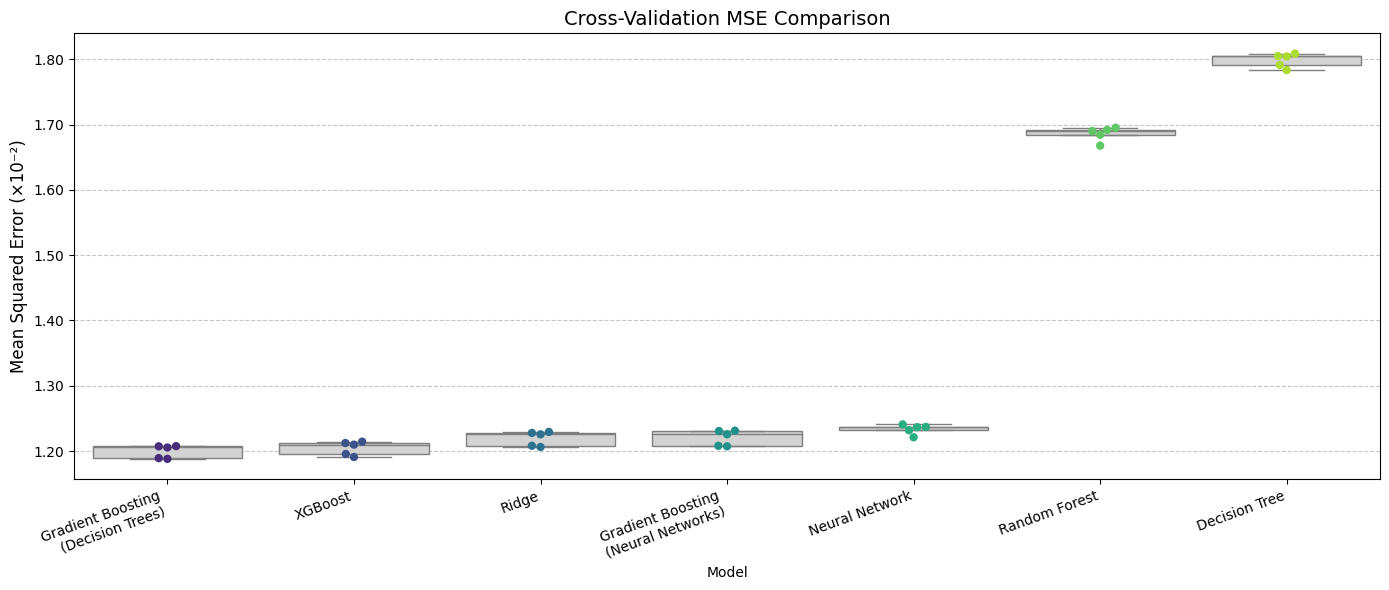

In [19]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Ridge': ridge_mse_scores,
    'Decision Tree': dt_mse_scores,
    'Random Forest': rf_mse_scores,
    'Neural Network': mlp_mse_scores,
    "GB (Decision Trees)": gb_mse_scores,
    'XGBoost': xgb_mse_scores,
    'GB (Neural Networks)': nn_gb_mse_scores
})

melted_df = results_df.melt(var_name='Model', value_name='MSE')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean MSE (best → worst)
model_order = (
    melted_df.groupby('Model')['MSE']
    .mean()
    .sort_values()
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='MSE',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='MSE',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis in 10^-2 scale
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x*1e2:.2f}'))
plt.ylabel('Mean Squared Error (×10⁻²)', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation MSE Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\oriol\AppData\Local\Temp\ipykernel_12764\2374248617.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


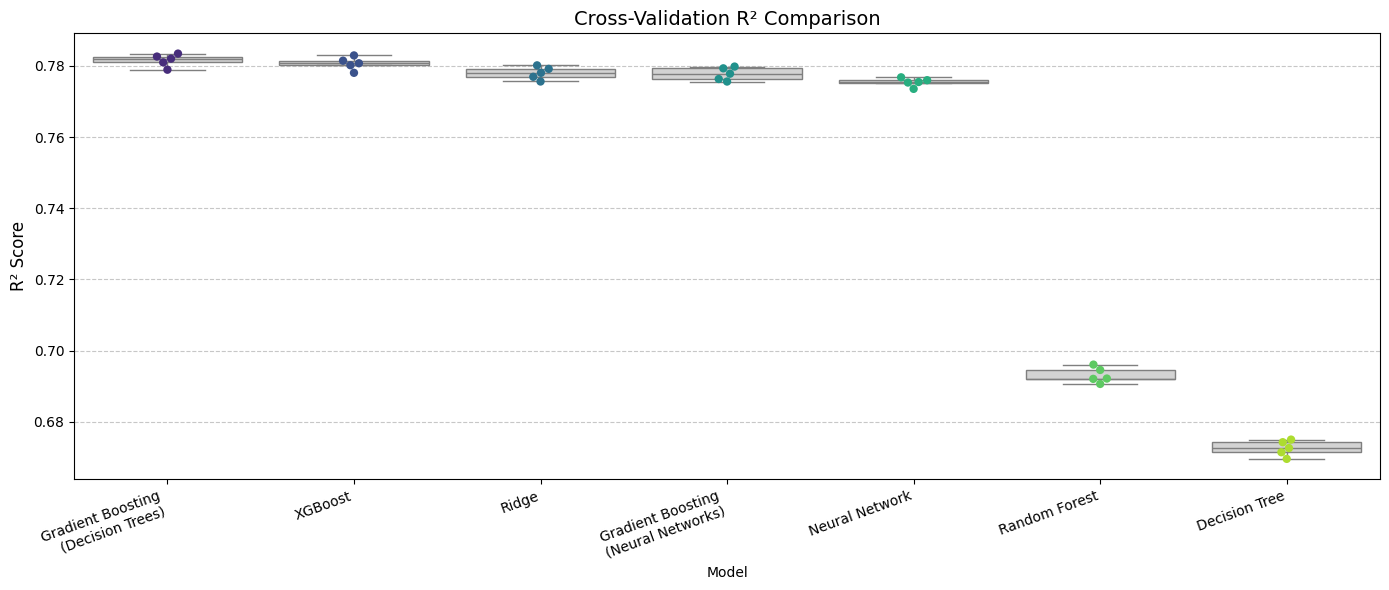

In [20]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Ridge': ridge_r2_scores,
    'Decision Tree': dt_r2_scores,
    'Random Forest': rf_r2_scores,
    'Neural Network': mlp_r2_scores,
    "GB (Decision Trees)": gb_r2_scores,
    'XGBoost': xgb_r2_scores,
    'GB (Neural Networks)': nn_gb_r2_scores
})

melted_df = results_df.melt(var_name='Model', value_name='R2')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean R² (best → worst = descending)
model_order = (
    melted_df.groupby('Model')['R2']
    .mean()
    .sort_values(ascending=False)
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='R2',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='R2',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation R² Comparison', fontsize=14)
plt.ylabel('R² Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### VISUALIZATION (BY MEDIAN)

C:\Users\oriol\AppData\Local\Temp\ipykernel_12764\1612917705.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


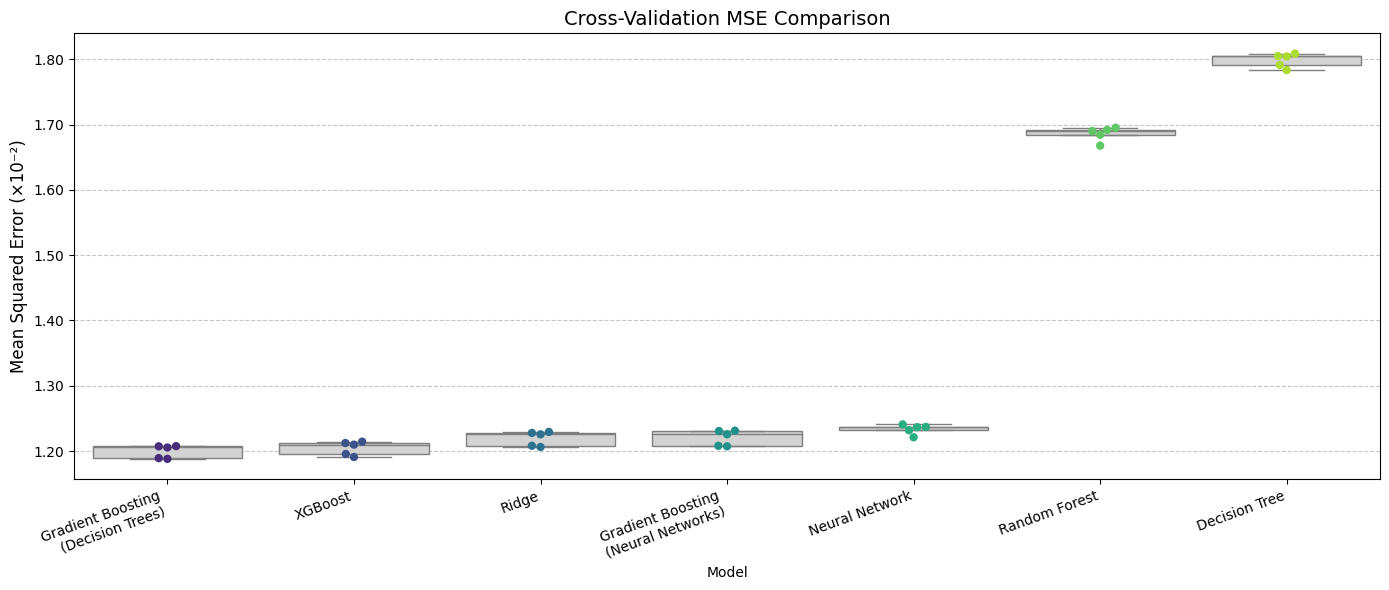

In [21]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Ridge': ridge_mse_scores,
    'Decision Tree': dt_mse_scores,
    'Random Forest': rf_mse_scores,
    'Neural Network': mlp_mse_scores,
    "GB (Decision Trees)": gb_mse_scores,
    'XGBoost': xgb_mse_scores,
    'GB (Neural Networks)': nn_gb_mse_scores
})

melted_df = results_df.melt(var_name='Model', value_name='MSE')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean MSE (best → worst)
model_order = (
    melted_df.groupby('Model')['MSE']
    .median()
    .sort_values()
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='MSE',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='MSE',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis in 10^-2 scale
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x*1e2:.2f}'))
plt.ylabel('Mean Squared Error (×10⁻²)', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation MSE Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\oriol\AppData\Local\Temp\ipykernel_12764\1894387692.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


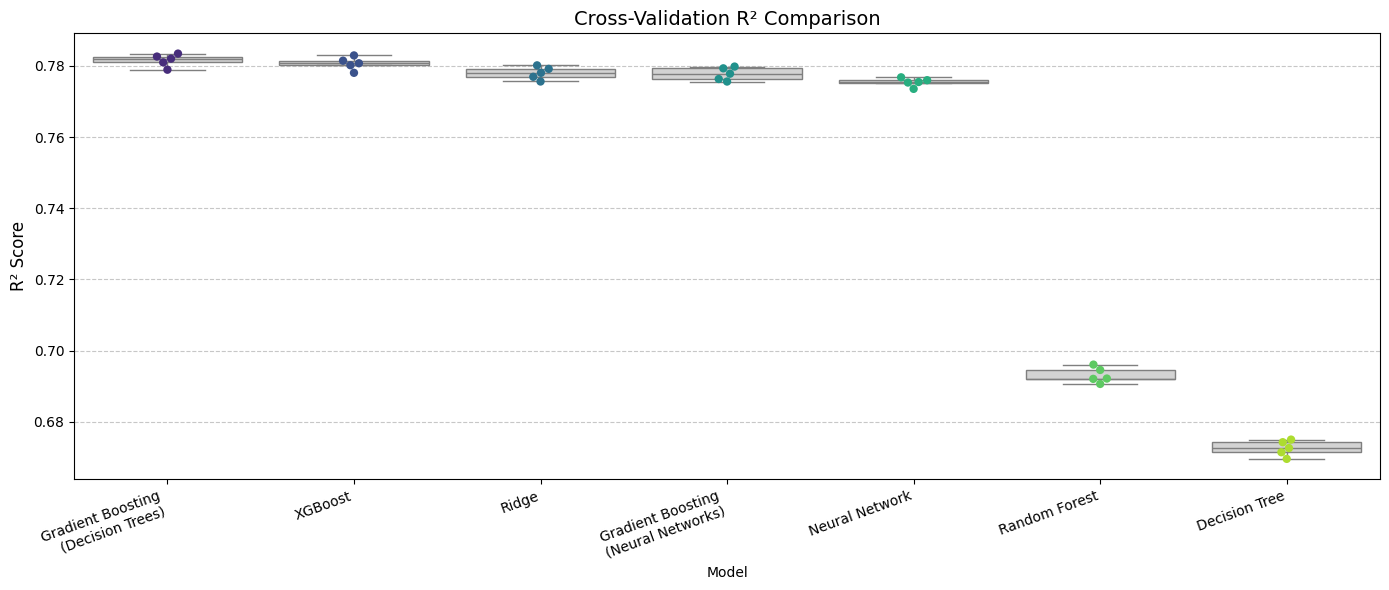

In [22]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Ridge': ridge_r2_scores,
    'Decision Tree': dt_r2_scores,
    'Random Forest': rf_r2_scores,
    'Neural Network': mlp_r2_scores,
    "GB (Decision Trees)": gb_r2_scores,
    'XGBoost': xgb_r2_scores,
    'GB (Neural Networks)': nn_gb_r2_scores
})

melted_df = results_df.melt(var_name='Model', value_name='R2')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean R² (best → worst = descending)
model_order = (
    melted_df.groupby('Model')['R2']
    .median()
    .sort_values(ascending=False)
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='R2',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='R2',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation R² Comparison', fontsize=14)
plt.ylabel('R² Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### VISUALIZATION (WITHOUT DTs AND RFs)

C:\Users\oriol\AppData\Local\Temp\ipykernel_12764\2935190585.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


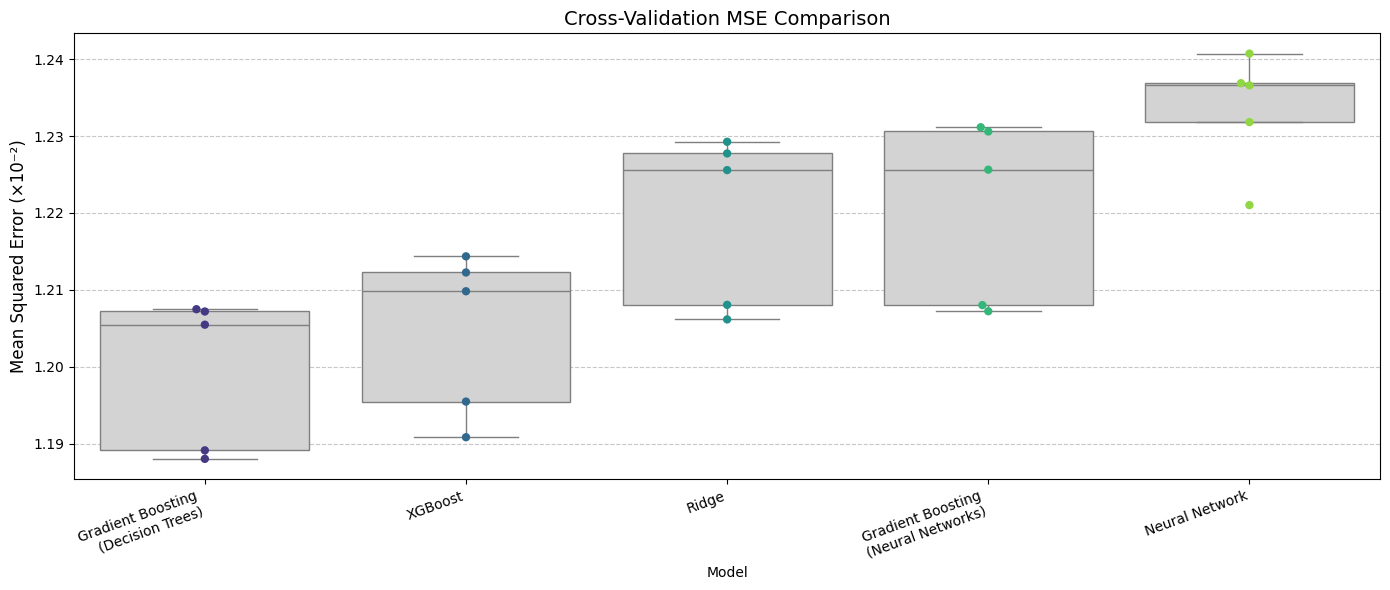

In [23]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Ridge': ridge_mse_scores,
    'Neural Network': mlp_mse_scores,
    "GB (Decision Trees)": gb_mse_scores,
    'XGBoost': xgb_mse_scores,
    'GB (Neural Networks)': nn_gb_mse_scores
})

melted_df = results_df.melt(var_name='Model', value_name='MSE')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean MSE (best → worst)
model_order = (
    melted_df.groupby('Model')['MSE']
    .median()
    .sort_values()
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='MSE',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='MSE',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis in 10^-2 scale
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x*1e2:.2f}'))
plt.ylabel('Mean Squared Error (×10⁻²)', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation MSE Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\oriol\AppData\Local\Temp\ipykernel_12764\3608224838.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


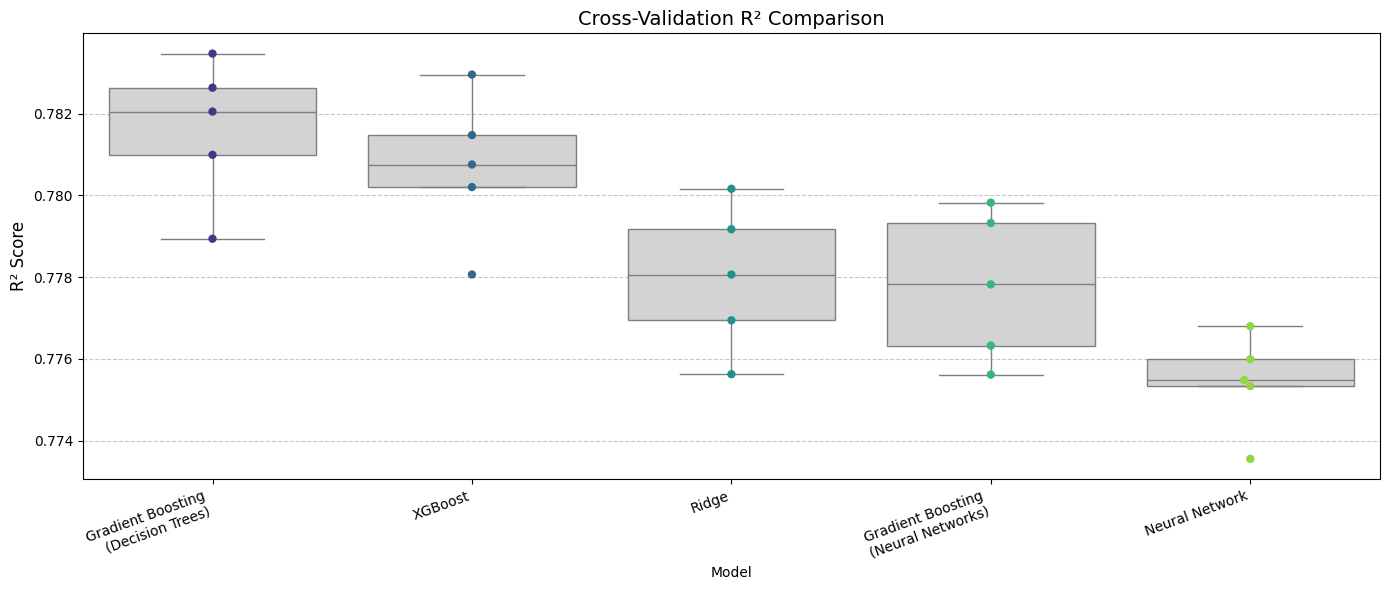

In [24]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Ridge': ridge_r2_scores,
    'Neural Network': mlp_r2_scores,
    "GB (Decision Trees)": gb_r2_scores,
    'XGBoost': xgb_r2_scores,
    'GB (Neural Networks)': nn_gb_r2_scores
})

melted_df = results_df.melt(var_name='Model', value_name='R2')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean R² (best → worst = descending)
model_order = (
    melted_df.groupby('Model')['R2']
    .median()
    .sort_values(ascending=False)
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='R2',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='R2',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation R² Comparison', fontsize=14)
plt.ylabel('R² Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()